【Data Scaling(데이터 스케일링)】
- 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업을 피처 스케일링(feature scaling)이라고 한다.
- 피처(feature)=컬럼(column) 들마다 데이터의 값이 범위가 다 제각각이거나 단위가 다른 경우 데이터를 학습을 할때 0으로 수렴하거나 무한으로 발산할 수 있다.
  - 분석시에 변수들이 너무 스케일이 다를 경우  => 변수들의 단위 차이로 인해 숫자의 스케일이 크게 달라지는 경우
  - 신경망 학습시에 => 데이터셋의 값이 들쑥날쑥하거나, 매우 큰 경우에는 cost의 값이 발산하여 정상적인 학습이 이루어지지 않습니다.

- 이런 경우 데이터 스켈링을 통해 모든 피처들의 데이터 분포나 범위를 동일하게 조정해 줄 수 있다.
- Scaling 메서드는 scikit-learn의 preprocessing에서 제공한다.
- sklearn에서 제공하는 기본 Scaling 종류
   - StandardScaler : 평균이 0 분산이 1인 정규분포로 변환
   - MinMaxScaler :  0 ~ 1 사이의 실수로 변환, 타이타닉 생존자 예측(0 또는 1)과 같은 분류 문제보다는, 아파트 실거래가격 예측과 같은 회귀 문제를 해결할 때 더 적합한 스케일링 기법
   - RobustScaler : 중앙값이 0, 중앙값을 0으로, IQR을 1로 변환, StandardScaler에 비해 이상치의 영향이 적어진다는 장점
   - MaxAbsScaler : 모든 피처들의 절댓값이 0과 1 사이에 놓이도록 변환, 극단적인 이상치에는 민감할 수 있으므로 꼭 이상치를 제거
   - Normalizer :  row를 기준으로 row(data point)마다 정규화를 진행, 한 행의 모든 features 사이에 유클리드 거리가 1이 되도록 데이터값을 변환, Normalizer를 사용하면 학습 속도도 빨라지고 과대적합 확률을 낮춤

In [4]:
# '파이썬 라이브러리를 활용한 머신러닝'의 저자가 제공한 라이브러리
# !uv add mglearn

In [45]:
import mglearn

In [46]:
print(dir(mglearn))

['ReBl', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'cm2', 'cm3', 'datasets', 'discrete_scatter', 'plot_2d_separator', 'plot_agglomerative', 'plot_animal_tree', 'plot_cross_validation', 'plot_dbscan', 'plot_decomposition', 'plot_grid_search', 'plot_helpers', 'plot_improper_preprocessing', 'plot_interactive_tree', 'plot_kmeans', 'plot_kneighbors_regularization', 'plot_knn_classification', 'plot_knn_regression', 'plot_linear_regression', 'plot_linear_svc_regularization', 'plot_metrics', 'plot_nmf', 'plot_nn_graphs', 'plot_pca', 'plot_rbf_svm_parameters', 'plot_ridge', 'plot_scaling', 'plot_tree_nonmonotonous', 'plots', 'tools']


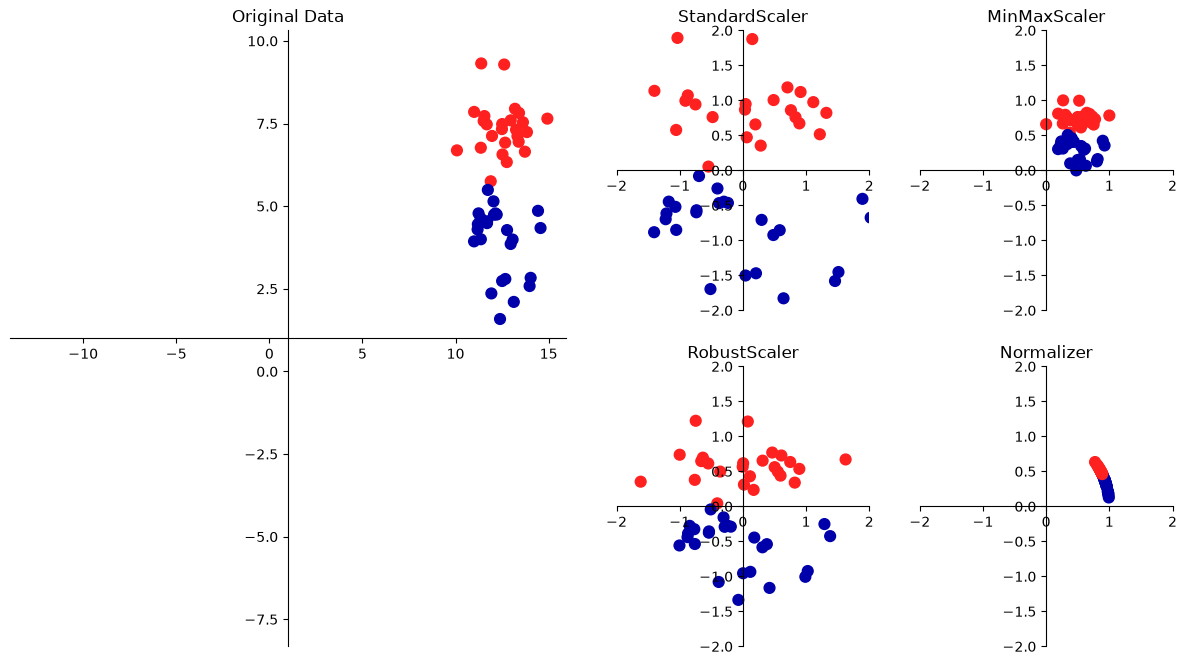

In [47]:
mglearn.plot_scaling.plot_scaling()

1. ## **`MaxAbsScaler`**

- 데이터의 **절대값이 1을 넘지 않도록** 스케일링
- 음수와 양수 값이 섞인 sparse 데이터에 적합
- 이상치에 민감하며, 분류보다는 회귀분석에서 유용


In [8]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform([[-1, 23], [0, 3], [1, -2]])
X_scaled


array([[-1.        ,  1.        ],
       [ 0.        ,  0.13043478],
       [ 1.        , -0.08695652]])

2. MinMaxScaler

- **최소-최대 정규화**: 데이터를 `[0, 1]` 범위로 변환
- 정규분포가 아닐때 사용
- 이상치에 민감
- 분류보다 회귀에 유용

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform([[1, 2], [3, 4], [5, 6]])
X_scaled


array([[0. , 0. ],
       [0.5, 0.5],
       [1. , 1. ]])

2.3 StandardScaler

- **Z-score 정규화**: 평균을 0, 표준편차를 1로 변환
- 이상치 영향을 받으므로 이상치가 없을때 사용
- 회귀보다는 분류분석에서 유용

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform([[1, 2], [3, 4], [5, 6]])
X_scaled


array([[-1.22474487, -1.22474487],
       [ 0.        ,  0.        ],
       [ 1.22474487,  1.22474487]])

2.4 Normalizer
- 각 행의 벡터 크기를 1로 정규화 (L1, L2, Max 노름 사용 가능)

In [11]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l2')
X_normalized = normalizer.transform([[1, 2], [3, 4]])
X_normalized


array([[0.4472136 , 0.89442719],
       [0.6       , 0.8       ]])

2.5 RobustScaler
- **중앙값과 IQR(사분위 범위) 기반 정규화**
- 이상치(Outlier)에 강한 정규화 방법

In [12]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# 예제 데이터
data = {
    'Income': [3000, 3200, 3400, 100000, 3600],  # 이상치 존재
    'Age': [25, 26, 27, 28, 29]
}
df = pd.DataFrame(data)
print(" 원본 데이터:\n", df)

# RobustScaler 객체 생성 및 적용
scaler = RobustScaler()
scaled_data = scaler.fit_transform(df)

# 결과를 DataFrame으로 변환
df_scaled = pd.DataFrame(scaled_data, columns=['Income_scaled', 'Age_scaled'])
print("RobustScaler 결과:\n", df_scaled)

# 3          241.5         0.5  이상이 영향 작음

 원본 데이터:
    Income  Age
0    3000   25
1    3200   26
2    3400   27
3  100000   28
4    3600   29
RobustScaler 결과:
    Income_scaled  Age_scaled
0           -1.0        -1.0
1           -0.5        -0.5
2            0.0         0.0
3          241.5         0.5
4            0.5         1.0


| Feature 이름          | 설명      | 단위 |
| ------------------- | ------- | -- |
| `sepal length (cm)` | 꽃받침의 길이 | cm |
| `sepal width (cm)`  | 꽃받침의 너비 | cm |
| `petal length (cm)` | 꽃잎의 길이  | cm |
| `petal width (cm)`  | 꽃잎의 너비  | cm |


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import RobustScaler

In [14]:
iris = load_iris()
print(dir(iris))
print(iris.target)

iris = pd.DataFrame(iris.data, columns=iris.feature_names)

iris['Class'] = load_iris().target
iris['Class'] = iris['Class'].map({0:'Setosa', 1:'Versicolour', 2:'Virginica'})
iris.head()

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Class
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [15]:
from sklearn.model_selection import train_test_split


#X_관측값_훈련,X_관측값_테스트,y_정답_훈련,y_정답_테스트
X_train, X_test, y_train, y_test = train_test_split(iris.drop(columns='Class'), iris['Class'],   test_size=0.2) #  test_size=0.25.



In [16]:
X_train.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
81,5.5,2.4,3.7,1.0
120,6.9,3.2,5.7,2.3
91,6.1,3.0,4.6,1.4
68,6.2,2.2,4.5,1.5
109,7.2,3.6,6.1,2.5


In [17]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(120, 4) (120,)
(30, 4) (30,)


In [18]:
print(y_train.value_counts())

Class
Virginica      42
Setosa         40
Versicolour    38
Name: count, dtype: int64


In [19]:
print(y_test.value_counts())

Class
Versicolour    12
Setosa         10
Virginica       8
Name: count, dtype: int64


In [20]:
import seaborn as sns

In [21]:
print(type(y_train))
print(y_train.head())

<class 'pandas.Series'>
81     Versicolour
120      Virginica
91     Versicolour
68     Versicolour
109      Virginica
Name: Class, dtype: str


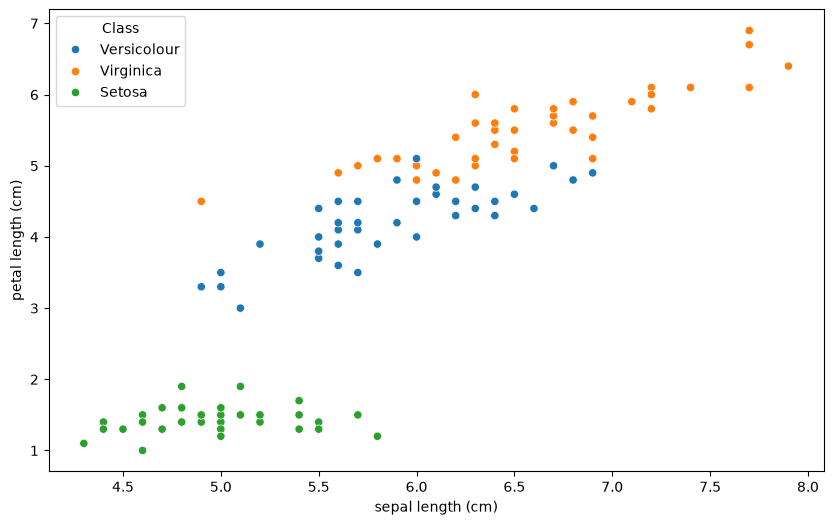

In [22]:
fig =sns.scatterplot(data=X_train, x=X_train.iloc[:,0], y=X_train.iloc[:,2], hue=y_train)
fig.figure.set_size_inches(10,6)

In [23]:
StdScaler = StandardScaler()

# Train데이터의 fitting과 스케일링
StdScaler.fit(X_train)  #fit()은 학습을 시키는 메소드이다.
X_train_sc = StdScaler.transform(X_train)  #transform() 실제로 학습시킨 것을 적용하는 메소드이다.

print('\t\t(min, max)  (mean,std)')
print('Train_scaled (%.2f, %.2f) ( %.2f, %.2f)'%(X_train_sc.min(), X_train_sc.max(), X_train_sc.mean(),X_train_sc.std()))

		(min, max)  (mean,std)
Train_scaled (-2.35, 3.02) ( 0.00, 1.00)


In [24]:
StdScaler2 = StandardScaler()
StdScaler2.fit_transform(X_train)

array([[-0.38863006, -1.45587267, -0.0279858 , -0.27870223],
       [ 1.32501431,  0.33597062,  1.11041949,  1.40647405],
       [ 0.34578895, -0.11199021,  0.48429658,  0.23981355],
       [ 0.46819212, -1.90383349,  0.42737632,  0.36944249],
       [ 1.69222382,  1.23189226,  1.33810055,  1.66573193],
       [-1.12304908, -0.11199021, -1.33715188, -1.31573378],
       [ 0.83540163, -0.11199021,  0.82581817,  1.01758721],
       [-1.61266176, -1.67985308, -1.39407214, -1.18610484],
       [ 0.9578048 , -0.11199021,  0.37045605,  0.23981355],
       [-0.38863006,  2.57577472, -1.33715188, -1.31573378],
       [ 0.71299846, -0.55995103,  1.05349923,  1.14721616],
       [-1.12304908, -1.23189226,  0.42737632,  0.62870038],
       [ 0.59059529, -0.33597062,  1.05349923,  0.75832932],
       [ 0.83540163, -0.11199021,  0.99657896,  0.75832932],
       [ 0.22338578, -1.90383349,  0.142775  , -0.27870223],
       [ 1.69222382, -0.11199021,  1.16733975,  0.49907144],
       [ 1.08020797,  0.

In [25]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,-0.388630,1.325014,0.345789,0.468192,1.692224,-1.123049,0.835402,-1.612662,0.957805,-0.388630,...,-0.143824,-0.266227,-0.021421,-0.388630,0.223386,0.468192,-0.388630,-0.021421,-1.000646,2.304240
1,-1.455873,0.335971,-0.111990,-1.903833,1.231892,-0.111990,-0.111990,-1.679853,-0.111990,2.575775,...,-0.335971,-0.335971,2.127814,-1.679853,-0.783931,0.783931,-1.007912,-0.559951,-2.351794,1.679853
2,-0.027986,1.110419,0.484297,0.427376,1.338101,-1.337152,0.825818,-1.394072,0.370456,-1.337152,...,0.256616,-0.084906,-1.450992,0.142775,0.768898,0.939659,0.370456,0.768898,-0.141826,1.679622
3,-0.278702,1.406474,0.239814,0.369442,1.665732,-1.315734,1.017587,-1.186105,0.239814,-1.315734,...,0.110185,0.110185,-1.315734,0.110185,0.499071,1.406474,-0.019444,1.536103,-0.278702,1.276845


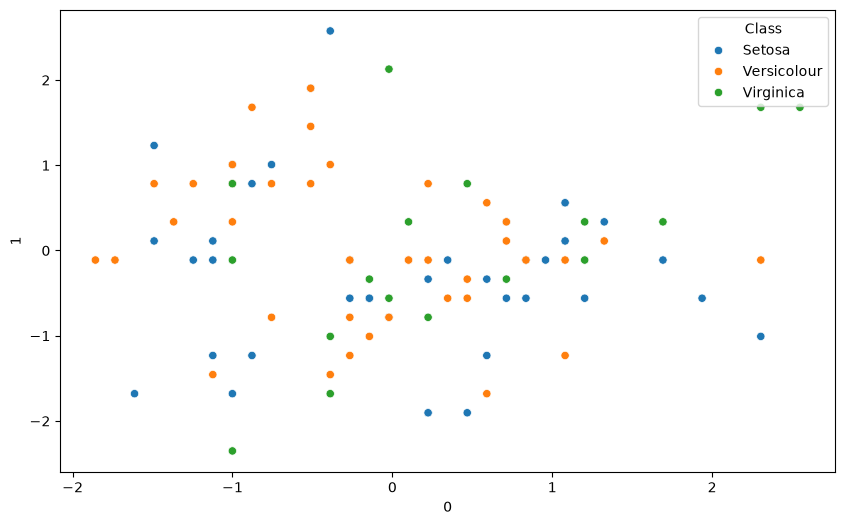

In [26]:
fig =sns.scatterplot(data=xt, x=xt.iloc[0,:], y=xt.iloc[1,], hue=y_train)
fig.figure.set_size_inches(10,6)

In [27]:
from sklearn.preprocessing import MinMaxScaler

MmScaler = MinMaxScaler()

# Train 데이터의 fitting과 스케일링
# fit()은 학습을 시키는 메소드이다.
MmScaler.fit(X_train)

#transform()은 실제로 학습시킨 것을 적용하는 메소드이다.
X_train_sc = MmScaler.transform(X_train)
print(X_train_sc.shape)

print('\t\t(min, max)  (mean,std)')
print('Train_scaled (%.2f, %.2f) ( %.2f, %.2f)'%(X_train_sc.min(), X_train_sc.max(), X_train_sc.mean(),X_train_sc.std()))

(120, 4)
		(min, max)  (mean,std)
Train_scaled (0.00, 1.00) ( 0.45, 0.26)


(480,)


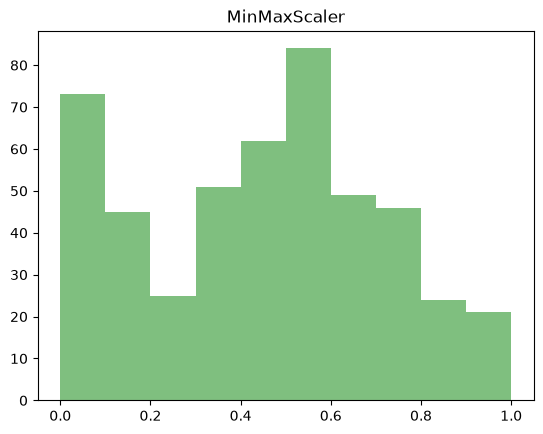

In [28]:
X_train_sc_flat = X_train_sc.flatten()
print(X_train_sc_flat.shape)
#print(X_train_sc_flat)
plt.hist(X_train_sc_flat, color='green', alpha=0.5)
plt.title('MinMaxScaler')
plt.show()

In [29]:
xt = pd.DataFrame(X_train_sc).T

In [30]:
xt.iloc[0, :].shape

(120,)

In [31]:
xt.iloc[1, :].shape

(120,)

In [32]:
xt.shape

(4, 120)

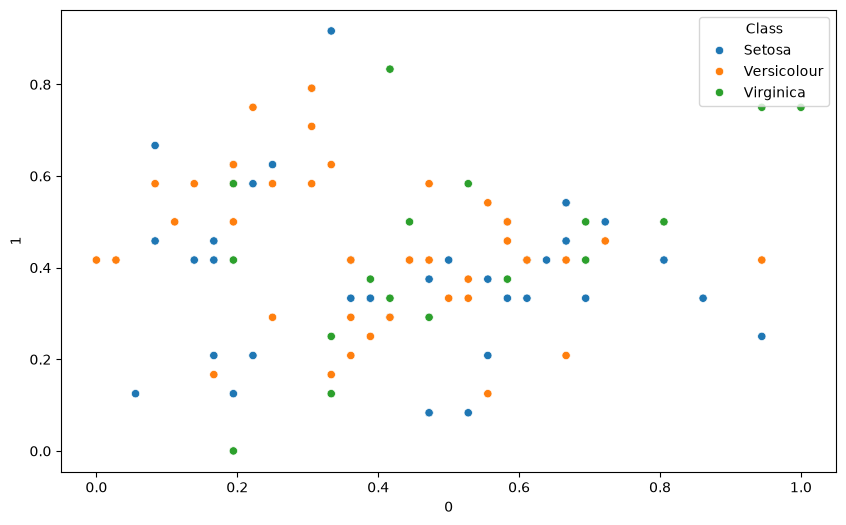

In [33]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [34]:
from sklearn.preprocessing import MaxAbsScaler

MaScaler = MaxAbsScaler()

# Train 데이터의 fitting과 스케일링
MaScaler.fit(X_train)
X_train_sc = MaScaler.transform(X_train)


print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))

		(min, max) (mean, std)
Train_scaled (0.04, 1.00) (0.61, 0.24)


In [35]:
X_train_sc.shape

(120, 4)

In [36]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,0.696203,0.873418,0.772152,0.784810,0.911392,0.620253,0.822785,0.569620,0.835443,0.696203,...,0.721519,0.708861,0.734177,0.696203,0.759494,0.784810,0.696203,0.734177,0.632911,0.974684
1,0.545455,0.727273,0.681818,0.500000,0.818182,0.681818,0.681818,0.522727,0.681818,0.954545,...,0.659091,0.659091,0.909091,0.522727,0.613636,0.772727,0.590909,0.636364,0.454545,0.863636
2,0.536232,0.826087,0.666667,0.652174,0.884058,0.202899,0.753623,0.188406,0.637681,0.202899,...,0.608696,0.521739,0.173913,0.579710,0.739130,0.782609,0.637681,0.739130,0.507246,0.971014
3,0.400000,0.920000,0.560000,0.600000,1.000000,0.080000,0.800000,0.120000,0.560000,0.080000,...,0.520000,0.520000,0.080000,0.520000,0.640000,0.920000,0.480000,0.960000,0.400000,0.880000


In [37]:
xt.shape

(4, 120)

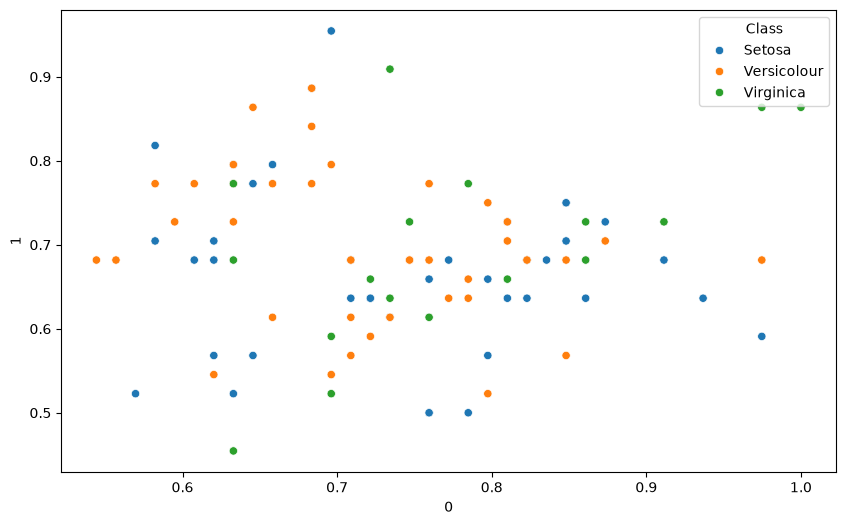

In [38]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [39]:
from sklearn.preprocessing import RobustScaler

RuScaler = RobustScaler()

# Train 데이터의 fitting과 스케일링
RuScaler.fit(X_train)
X_train_sc = RuScaler.transform(X_train)

print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))

		(min, max) (mean, std)
Train_scaled (-2.00, 2.80) (-0.02, 0.66)


In [40]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,-0.192308,0.884615,0.269231,0.346154,1.115385,-0.653846,0.576923,-0.961538,0.653846,-0.192308,...,-0.038462,-0.115385,0.038462,-0.192308,0.192308,0.346154,-0.192308,0.038462,-0.576923,1.500000
1,-1.200000,0.400000,0.000000,-1.600000,1.200000,0.000000,0.000000,-1.400000,0.000000,2.400000,...,-0.200000,-0.200000,2.000000,-1.400000,-0.600000,0.800000,-0.800000,-0.400000,-2.000000,1.600000
2,-0.184397,0.382979,0.070922,0.042553,0.496454,-0.836879,0.241135,-0.865248,0.014184,-0.836879,...,-0.042553,-0.212766,-0.893617,-0.099291,0.212766,0.297872,0.014184,0.212766,-0.241135,0.666667
3,-0.200000,0.666667,0.066667,0.133333,0.800000,-0.733333,0.466667,-0.666667,0.066667,-0.733333,...,0.000000,0.000000,-0.733333,0.000000,0.200000,0.666667,-0.066667,0.733333,-0.200000,0.600000


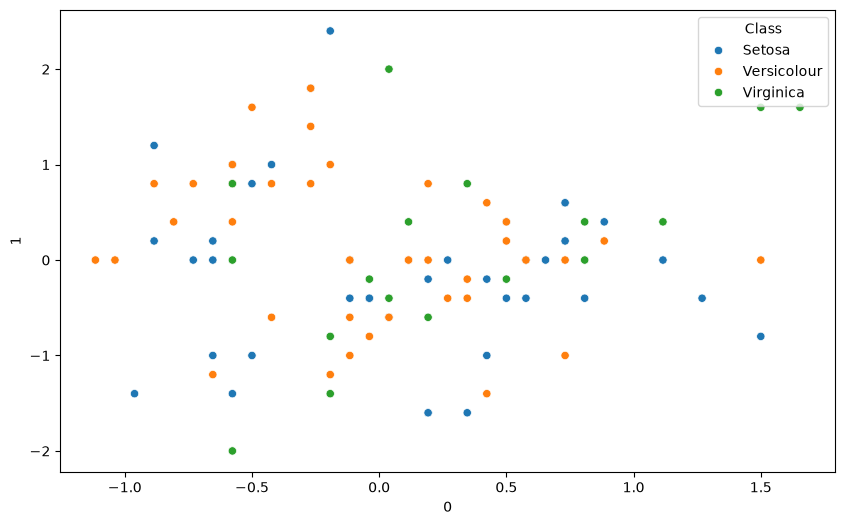

In [41]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [42]:
from sklearn.preprocessing import Normalizer

NoScaler = Normalizer()


# Train 데이터의 fitting과 스케일링
NoScaler.fit(X_train)
X_train_sc = NoScaler.transform(X_train)


print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))


		(min, max) (mean, std)
Train_scaled (0.01, 0.86) (0.44, 0.24)


In [43]:
xt = pd.DataFrame(X_train_sc.T)

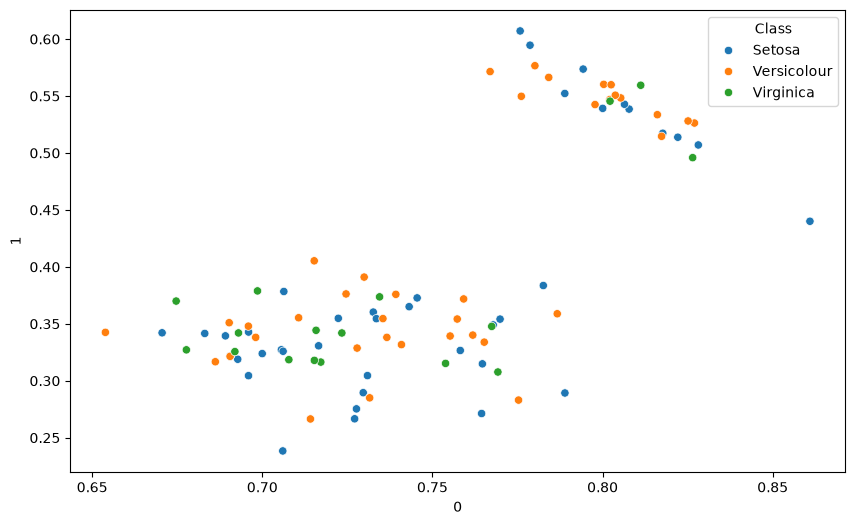

In [44]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)